Import des librairies et chargement des données

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Charger les données
df = pd.read_csv('Nat_Gas.csv')

# La colonne "Dates" en datetime, "Prices" en float
df.columns = ['Dates', 'Prices']
df['Dates'] = pd.to_datetime(df['Dates'])
df = df.sort_values('Dates').reset_index(drop=True)

print(df.head())
print(f"\nPériode : {df['Dates'].min()} → {df['Dates'].max()}")
print(f"Nombre de points : {len(df)}")

       Dates  Prices
0 2020-10-31    10.1
1 2020-11-30    10.3
2 2020-12-31    11.0
3 2021-01-31    10.9
4 2021-02-28    10.9

Période : 2020-10-31 00:00:00 → 2024-09-30 00:00:00
Nombre de points : 48


Visualisation et identification des patterns

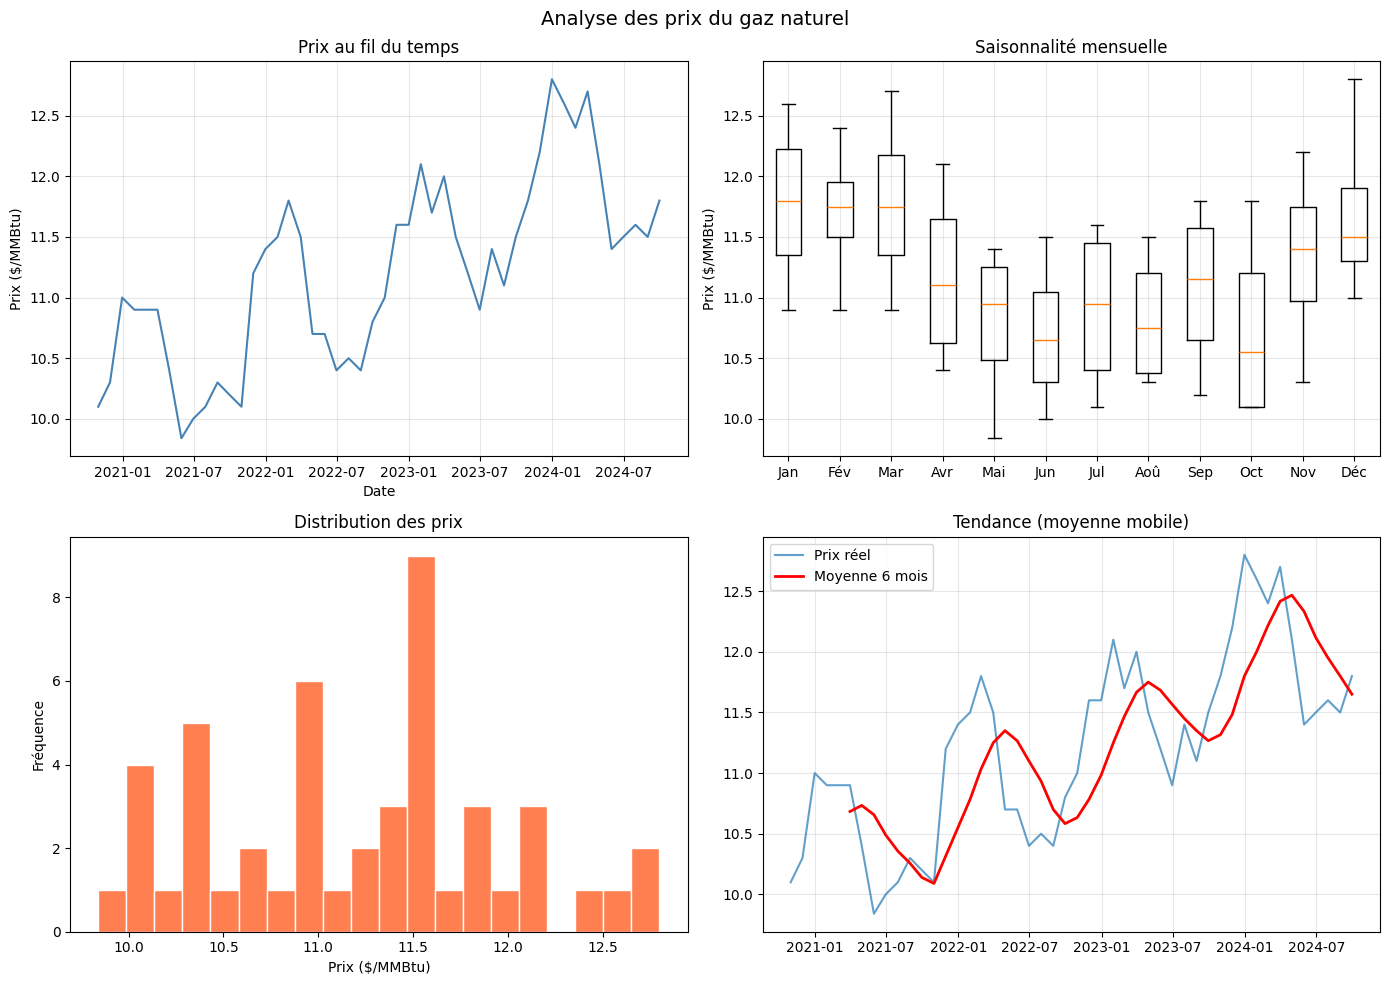

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analyse des prix du gaz naturel', fontsize=14)

# 1. Série temporelle complète
ax1 = axes[0, 0]
ax1.plot(df['Dates'], df['Prices'], color='steelblue', linewidth=1.5)
ax1.set_title('Prix au fil du temps')
ax1.set_xlabel('Date')
ax1.set_ylabel('Prix ($/MMBtu)')
ax1.grid(True, alpha=0.3)

# 2. Saisonnalité mensuelle (boxplot par mois)
df['Month'] = df['Dates'].dt.month
monthly_data = [df[df['Month'] == m]['Prices'].values for m in range(1, 13)]
month_names = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

ax2 = axes[0, 1]
ax2.boxplot(monthly_data, labels=month_names)
ax2.set_title('Saisonnalité mensuelle')
ax2.set_ylabel('Prix ($/MMBtu)')
ax2.grid(True, alpha=0.3)

# 3. Distribution des prix
ax3 = axes[1, 0]
ax3.hist(df['Prices'], bins=20, color='coral', edgecolor='white')
ax3.set_title('Distribution des prix')
ax3.set_xlabel('Prix ($/MMBtu)')
ax3.set_ylabel('Fréquence')

# 4. Variations mensuelles (prix - moyenne glissante)
df['Rolling_Mean'] = df['Prices'].rolling(window=6).mean()
ax4 = axes[1, 1]
ax4.plot(df['Dates'], df['Prices'], label='Prix réel', alpha=0.7)
ax4.plot(df['Dates'], df['Rolling_Mean'], label='Moyenne 6 mois', linewidth=2, color='red')
ax4.set_title('Tendance (moyenne mobile)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gas_price_analysis.png', dpi=150)
plt.show()

 Construction du modèle (tendance + saisonnalité)

In [4]:
# Convertir les dates en nombre de mois depuis le début (variable numérique)
df['Time_Index'] = (df['Dates'].dt.year - df['Dates'].dt.year.min()) * 12 \
                   + df['Dates'].dt.month

# Features saisonnières : encodage sin/cos du mois
# Permet de capturer la nature cyclique (jan=jan chaque année)
df['Sin_Month'] = np.sin(2 * np.pi * df['Dates'].dt.month / 12)
df['Cos_Month'] = np.cos(2 * np.pi * df['Dates'].dt.month / 12)

# Features pour le modèle
X = df[['Time_Index', 'Sin_Month', 'Cos_Month']].values
y = df['Prices'].values

# Modèle polynomial d'ordre 3 pour la tendance + saisonnalité
# PolynomialFeatures crée les combinaisons : t, t², t³, sin, cos, t*sin, etc.
model = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    LinearRegression()
)
model.fit(X, y)

# Évaluation sur les données d'entraînement
y_pred = model.predict(X)
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f"RMSE sur données d'entraînement : {rmse:.4f} $/MMBtu")

RMSE sur données d'entraînement : 0.1586 $/MMBtu


Validation et visualisation du modèle

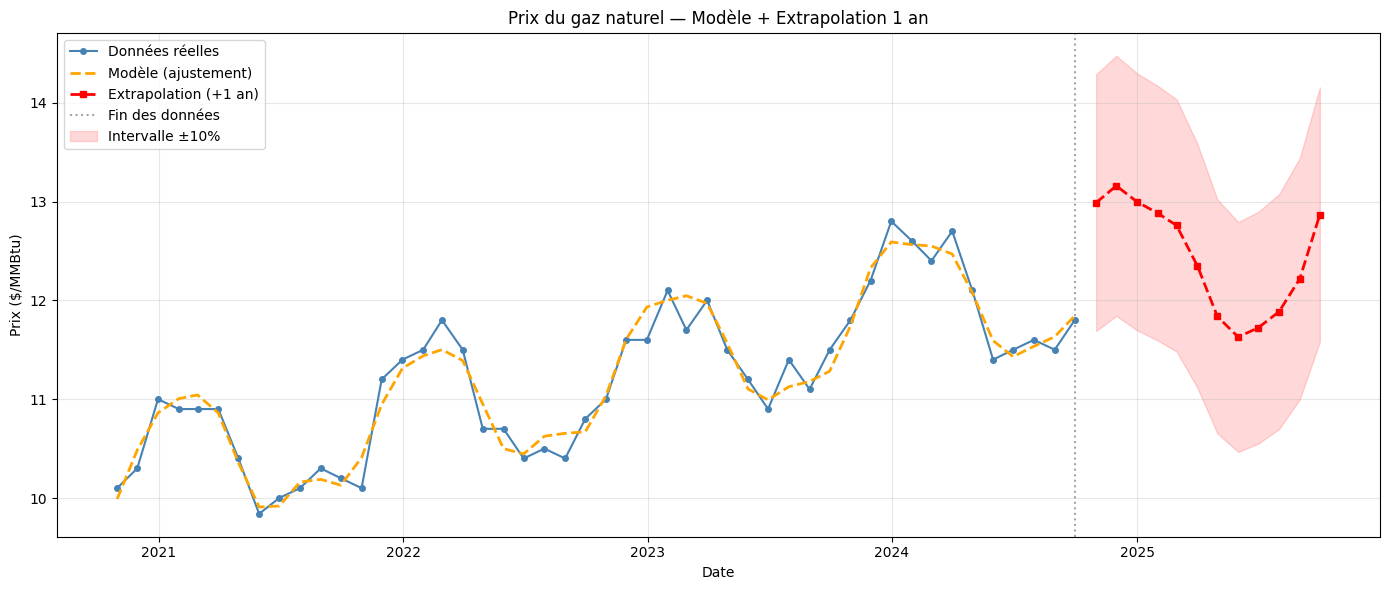

In [5]:
# Extrapolation sur 1 an supplémentaire
last_date = df['Dates'].max()
future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=12,
    freq='MS'  # Month Start
)

# Calculer le time_index pour les dates futures
ref_year = df['Dates'].dt.year.min()
future_time_index = (future_dates.year - ref_year) * 12 + future_dates.month
future_sin = np.sin(2 * np.pi * future_dates.month / 12)
future_cos = np.cos(2 * np.pi * future_dates.month / 12)

X_future = np.column_stack([future_time_index, future_sin, future_cos])
future_prices = model.predict(X_future)

# Visualisation finale
plt.figure(figsize=(14, 6))
plt.plot(df['Dates'], df['Prices'], 'o-', label='Données réelles', 
         color='steelblue', markersize=4, linewidth=1.5)
plt.plot(df['Dates'], y_pred, '--', label='Modèle (ajustement)', 
         color='orange', linewidth=2)
plt.plot(future_dates, future_prices, 's--', label='Extrapolation (+1 an)', 
         color='red', markersize=5, linewidth=2)

plt.axvline(x=last_date, color='gray', linestyle=':', alpha=0.7, label='Fin des données')
plt.fill_between(future_dates, future_prices * 0.9, future_prices * 1.1,
                 alpha=0.15, color='red', label='Intervalle ±10%')

plt.title('Prix du gaz naturel — Modèle + Extrapolation 1 an')
plt.xlabel('Date')
plt.ylabel('Prix ($/MMBtu)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gas_price_model.png', dpi=150)
plt.show()

 La fonction finale estimate_price(date)

In [6]:
def estimate_price(date_input):
   
    # Convertir en datetime si nécessaire
    if isinstance(date_input, str):
        date = pd.to_datetime(date_input)
    else:
        date = pd.Timestamp(date_input)
    
    # Construire les features identiques à l'entraînement
    ref_year = df['Dates'].dt.year.min()
    time_index = (date.year - ref_year) * 12 + date.month
    sin_month = np.sin(2 * np.pi * date.month / 12)
    cos_month = np.cos(2 * np.pi * date.month / 12)
    
    X_input = np.array([[time_index, sin_month, cos_month]])
    price = model.predict(X_input)[0]
    
    # Empêcher les valeurs négatives (les prix ne peuvent pas être négatifs)
    price = max(price, 0.01)
    
    return round(price, 4)


# --- Tests ---
print("=== Tests de la fonction estimate_price ===\n")

# Dates dans les données historiques
print(f"Oct 2020 (début données) : ${estimate_price('2020-10-31'):.2f}/MMBtu")
print(f"Jan 2022 (hiver)         : ${estimate_price('2022-01-15'):.2f}/MMBtu")
print(f"Été 2022                 : ${estimate_price('2022-07-01'):.2f}/MMBtu")
print(f"Sep 2024 (fin données)   : ${estimate_price('2024-09-30'):.2f}/MMBtu")

print()

# Extrapolations futures
print(f"Jan 2025 (extrapolation) : ${estimate_price('2025-01-01'):.2f}/MMBtu")
print(f"Été 2025                 : ${estimate_price('2025-07-01'):.2f}/MMBtu")
print(f"Sep 2025 (+1 an)         : ${estimate_price('2025-09-30'):.2f}/MMBtu")

=== Tests de la fonction estimate_price ===

Oct 2020 (début données) : $9.99/MMBtu
Jan 2022 (hiver)         : $11.44/MMBtu
Été 2022                 : $10.63/MMBtu
Sep 2024 (fin données)   : $11.84/MMBtu

Jan 2025 (extrapolation) : $13.00/MMBtu
Été 2025                 : $11.72/MMBtu
Sep 2025 (+1 an)         : $12.22/MMBtu
